In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred))
    )

def mase(y_true, y_pred, y_train):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_train = np.array(y_train)

    naive_error = np.mean(np.abs(np.diff(y_train)))
    return np.mean(np.abs(y_true - y_pred)) / naive_error

def theil_u(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    denominator = np.sqrt(np.mean(y_true ** 2) + np.mean(y_pred ** 2))
    u = rmse / denominator
    return u

# Load data
df = pd.read_excel('output_week.xlsx')

# Count occurrences and sort by week
data = df['WEEK'].value_counts().reset_index()
data.columns = ['WEEK', 'DATA']

# Convert week to a date representing the beginning of the week
data['WEEK_period'] = pd.to_datetime(
    data['WEEK'] + '-1',
    format='%G-%V-%u',
    errors='coerce'
)
data = data.sort_values('WEEK_period').reset_index(drop=True)

# ------------------------------
# Smoothing (moving average)
# ------------------------------
data['DATA_smooth'] = data['DATA'].rolling(window=5, center=True).mean()
data['DATA_smooth'].fillna(method='bfill', inplace=True)
data['DATA_smooth'].fillna(method='ffill', inplace=True)

# Data normalization
scaler = MinMaxScaler(feature_range=(0.1, 1))
data['y'] = scaler.fit_transform(data[['DATA_smooth']])

# ------------------------------
# Create lag variables
# ------------------------------
n_lags = 11  # You may test 12, 16, or 26 lags

for i in range(1, n_lags + 1):
    data[f'lag_{i}'] = data['y'].shift(i)

data = data.dropna().reset_index(drop=True)

# ------------------------------
# Prepare X and y
# ------------------------------
lag_cols = [f'lag_{i}' for i in range(n_lags, 0, -1)]

X = data[lag_cols].values.astype(np.float32)
y = data['y'].values.astype(np.float32)

# Reshape input for RNN
X = X.reshape((X.shape[0], X.shape[1], 1))

# ------------------------------
# Train/Test Split
# ------------------------------
split = int(len(X) * 0.7)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

/var/folders/36/lb3mdhtj2lldbybnz877q_hr0000gn/T/ipykernel_2577/513071530.py:52: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['DATA_smooth'].fillna(method='bfill', inplace=True)
/var/folders/36/lb3mdhtj2lldbybnz877q_hr0000gn/T/ipykernel_2577/513071530.py:52: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['DATA_smooth'].fillna(method='bfill', inplace=True)
/var/folders/36/lb3mdhtj2lldbybnz877q_hr0000gn/T/ipykernel_2577/513071530.p

In [2]:
# ------------------------------
# 7. SimpleRNN Model
# ------------------------------
model = Sequential()

# Single RNN layer
model.add(
    SimpleRNN(
        units=128,
        return_sequences=False,  # single layer
        input_shape=(n_lags, 1)
    )
)

# Output layer
model.add(Dense(1))

# ------------------------------
# 8. Compile Model
# ------------------------------
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

# ------------------------------
# 9. Early Stopping
# ------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# ------------------------------
# 10. Training
# ------------------------------
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# ------------------------------
# 11. Forecasting
# ------------------------------
y_pred = model.predict(X_test)

# ------------------------------
# Metrics
# ------------------------------
# Real-scale
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
y_pred_real = scaler.inverse_transform(y_pred.reshape(-1,1)).flatten()
y_train_real = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()

mae = mean_absolute_error(y_test_real, y_pred_real)
mape_real = np.mean(
    np.abs((y_test_real - y_pred_real) / y_test_real)
) * 100
smape_value = smape(y_test_real, y_pred_real)
mase_value = mase(y_test_real, y_pred_real, y_train_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)
u1 = theil_u(y_test_real, y_pred_real)

Epoch 1/200


/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0781 - val_loss: 0.0076
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0150 - val_loss: 0.0049
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0076 - val_loss: 0.0031
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0061 - val_loss: 0.0021
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0072 - val_loss: 0.0014
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0038 - val_loss: 0.0013
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0039 - val_loss: 0.0012
Epoch 8/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0039 - val_loss: 0.0017
Epoch 9/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0034 - val_loss: 0.0010
Epoch 10/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - val_loss: 9.0866e-04
Epoch 11/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0042 - val_loss: 0.0025
Epoch 12/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0051 - v

MAE: 0.7178
RMSE: 0.8477
R2: 0.8796
MAPE: 8.75%
SMAPE: 8.69%
MASE: 0.6903
Theil's U1: 0.06550827
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 890us/step


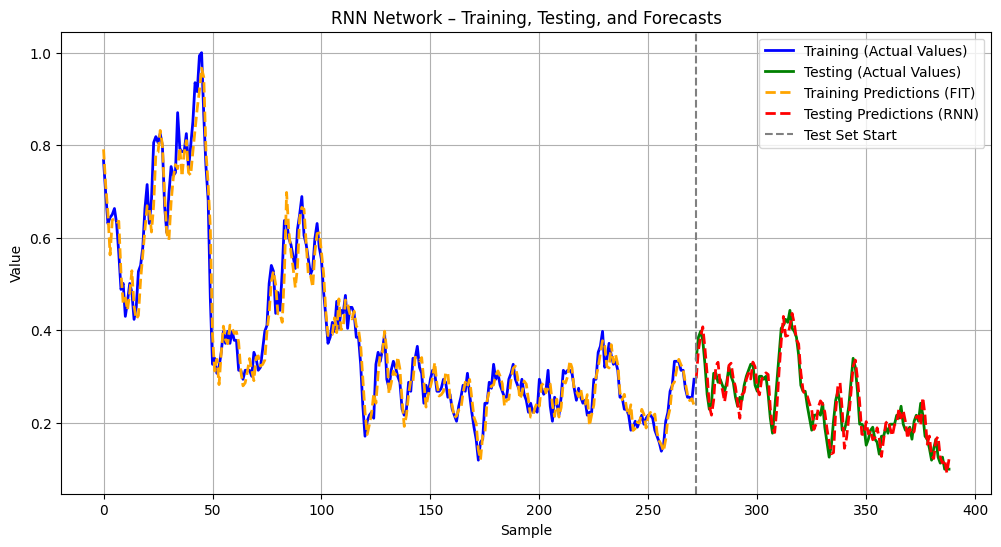

In [3]:
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")
print(f"MAPE: {mape_real:.2f}%")
print(f"SMAPE: {smape_value:.2f}%")
print(f"MASE: {mase_value:.4f}")
print("Theil's U1:", u1)
y_pred_train = model.predict(X_train)

plt.figure(figsize=(12,6))

# Indices
idx_train = np.arange(len(y_train))
idx_test = np.arange(len(y_train), len(y_train) + len(y_test))

# ---------------------------
# ACTUAL VALUES
# ---------------------------

# Training actual values
plt.plot(
    idx_train,
    y_train,
    label='Training (Actual Values)',
    color='blue',
    linewidth=2
)

# Testing actual values
plt.plot(
    idx_test,
    y_test,
    label='Testing (Actual Values)',
    color='green',
    linewidth=2
)

# ---------------------------
# PREDICTIONS
# ---------------------------

# Training predictions (fit)
plt.plot(
    idx_train,
    y_pred_train,
    label='Training Predictions (FIT)',
    color='orange',
    linestyle='--',
    linewidth=2
)

# Testing predictions
plt.plot(
    idx_test,
    y_pred,
    label='Testing Predictions (RNN)',
    color='red',
    linestyle='--',
    linewidth=2
)

# ---------------------------
# TRAIN/TEST SPLIT LINE
# ---------------------------

plt.axvline(
    x=len(y_train),
    color='gray',
    linestyle='--',
    label='Test Set Start'
)

plt.title('RNN Network – Training, Testing, and Forecasts')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Hyperparameter optimization was performed using a Random Search strategy.
def criar_rnn(units, num_layers, dropout, input_shape):

    model = Sequential()

    for i in range(num_layers):

        return_sequences = (i < num_layers - 1)

        model.add(
            SimpleRNN(
                units=units,
                activation='tanh',
                return_sequences=return_sequences,
                input_shape=input_shape if i == 0 else None
            )
        )

        if dropout > 0:
            model.add(Dropout(dropout))

    model.add(Dense(1))

    return model

def treinar_e_validar(model, X_tr, y_tr, X_val, y_val, lr, batch_size):

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mse"
    )

    model.fit(
        X_tr,
        y_tr,
        epochs=20,
        batch_size=batch_size,
        verbose=0
    )

    pred = model.predict(X_val).flatten()

    rmse = np.sqrt(mean_squared_error(y_val, pred))

    return rmse

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    shuffle=False  # importante para séries temporais
)

param_space = {
    "units": [32, 64, 128, 256],
    "num_layers": [1, 2],
    "dropout": [0.0, 0.1, 0.2],
    "lr": [1e-4, 1e-3],
    "batch_size": [16, 32]
}

from sklearn.model_selection import ParameterSampler

configs = list(
    ParameterSampler(
        param_space,
        n_iter=20,
        random_state=42
    )
)

bbest_loss = float("inf")
best_params = None

for params in configs:

    model = criar_rnn(
        units=params["units"],
        num_layers=params["num_layers"],
        dropout=params["dropout"],
        input_shape=(X_train.shape[1], X_train.shape[2])
    )

    loss = treinar_e_validar(
        model,
        X_tr,
        y_tr,
        X_val,
        y_val,
        lr=params["lr"],
        batch_size=params["batch_size"]
    )

    print(loss, params)

    if loss < best_loss:
        best_loss = loss
        best_params = params

print("Melhores parâmetros:", best_params)

/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
0.094257367627469 {'units': 32, 'num_layers': 1, 'lr': 0.0001, 'dropout': 0.2, 'batch_size': 32}


/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/stepWARNING:tensorflow:5 out of the last 14 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x16184a5f0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
0.05161232789441791 {'units': 64, 'num_layers': 2, 'lr': 0.001, 'dropout': 0.1, 'batch_size': 32}


/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
0.0482141807280008 {'units': 128, 'num_layers': 2, 'lr': 0.0001, 'dropout': 0.1, 'batch_size': 16}


/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
0.04672374511651037 {'units': 64, 'num_layers': 2, 'lr': 0.0001, 'dropout': 0.0, 'batch_size': 32}


/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
0.08882748586815595 {'units': 64, 'num_layers': 2, 'lr': 0.0001, 'dropout': 0.2, 'batch_size': 32}
Melhores parâmetros: {'units': 128, 'num_layers': 1, 'lr': 0.001, 'dropout': 0.0, 'batch_size': 16}


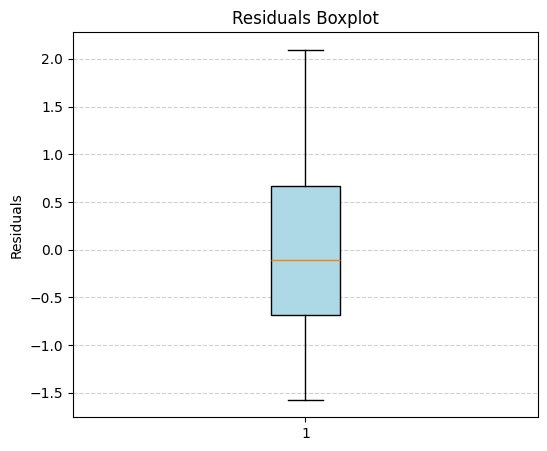

In [4]:
# Boxplot for residuals

residuals = y_test_real - y_pred_real
residuals = residuals.flatten()

plt.figure(figsize=(6,5))
plt.boxplot(residuals, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.title("Residuals Boxplot")
plt.ylabel("Residuals")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

residuals_df = pd.DataFrame({"residual_RNN": residuals})
residuals_df.to_csv("RNN_residuals.csv", index=False)